In [ ]:
/nfs/data/nii/data1/Analysis/GPUnet/ANALYSIS_incontext/SegFM3D/results/postchallenge_20250727_024854

In [11]:
from typing import final
from src.config import config
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
img_dir = os.path.join(config["DATA_DIR"], "3D_val_npz")
gts_dir = os.path.join(config["DATA_DIR"], "3D_val_gt_interactive_seg")
final_metrics = ['DSC_AUC', 'NSD_AUC', 'DSC_Final', 'NSD_Final',]

evalmetrics_june_df = pd.read_csv(os.path.join(config["RESULTS_DIR"], "simple", "norateam_metrics_2130_cases.csv"))    
#evalmetrics_current_df = pd.read_csv(os.path.join(config["RESULTS_DIR"], "postchallenge_20250728_152150", "norateam_metrics.csv"))
evalmetrics_current_df = pd.read_csv(os.path.join("/nfs/norasys/notebooks/camaret/segfm3d_nora_team/docker/submission/data/outputs/norateampostchallenge/norateampostchallenge_metrics.csv"))
evalmetrics_current_df['CaseName'] = evalmetrics_current_df['CaseName'].str.rstrip('.npz')
print(len(evalmetrics_june_df), len(evalmetrics_current_df))
print(evalmetrics_june_df[final_metrics].mean())
print(evalmetrics_current_df[final_metrics].mean())

2130 2116
DSC_AUC      2.479956
NSD_AUC      2.567132
DSC_Final    0.638593
NSD_Final    0.661417
dtype: float64
DSC_AUC      2.841303
NSD_AUC      3.056372
DSC_Final    0.751093
NSD_Final    0.813145
dtype: float64


In [12]:
missing_rows = evalmetrics_june_df[~evalmetrics_june_df['CaseName'].isin(evalmetrics_current_df['CaseName'])]
print(missing_rows[final_metrics].mean())

DSC_AUC      2.992132
NSD_AUC      2.502146
DSC_Final    0.773538
NSD_Final    0.643901
dtype: float64


In [8]:
#replace evalmetrics_june_df with evalmetrics_current_df entries when they exist

evalmetrics_june_df.set_index("CaseName", inplace=True)
evalmetrics_current_df.set_index("CaseName", inplace=True)
evalmetrics_june_df.update(evalmetrics_current_df)
evalmetrics_june_df.reset_index(inplace=True)
print(evalmetrics_june_df[final_metrics].mean())


DSC_AUC      2.842295
NSD_AUC      3.052729
DSC_Final    0.751240
NSD_Final    0.812032
dtype: float64


In [13]:
# in evalmetrics_june_df, keep rows where 'CaseName' is in evalmetrics_current_df['CaseName']
evalmetrics_june_df = evalmetrics_current_df[['CaseName']].merge(
    evalmetrics_june_df, 
    on='CaseName', 
    how='inner'
)

In [14]:

evalmetrics_more_stats_df = pd.read_csv("stats_by_case.csv")
# add "has_bbox" and "modality" columns from evalmetrics_more_stats_df to evalmetrics_current_df, matching on 'CaseName'

evalmetrics_current_df = evalmetrics_current_df.merge(
    evalmetrics_more_stats_df[['CaseName', 'has_bbox', 'modality']],
    on='CaseName',
    how='left',
)
evalmetrics_june_df = evalmetrics_june_df.merge(
    evalmetrics_more_stats_df[['CaseName', 'has_bbox', 'modality']],
    on='CaseName',
    how='left',
)

In [15]:
evalmetrics_current_df

,CaseName,TotalRunningTime,RunningTime_1,RunningTime_2,RunningTime_3,RunningTime_4,RunningTime_5,RunningTime_6,DSC_AUC,NSD_AUC,...,NSD_1,NSD_2,NSD_3,NSD_4,NSD_5,NSD_6,num_class,runtime_upperbound,has_bbox,modality
0,CT_AMOS_amos_0018,80.470730,12.860479,13.519857,14.077994,12.998374,13.362801,13.651225,3.371821,3.704851,...,0.865152,0.903232,0.921177,0.927279,0.938556,0.932446,15,1350,True,CT
1,CT_AMOS_amos_0021,80.654077,14.041740,12.933618,13.390354,13.231964,13.276788,13.779613,3.309677,3.520297,...,0.777906,0.828384,0.874420,0.885953,0.898315,0.894833,14,1260,True,CT
2,CT_AMOS_amos_0033,80.879992,13.151828,12.792516,15.167135,13.347838,13.396732,13.023944,3.434495,3.739709,...,0.886640,0.919162,0.927088,0.936169,0.943636,0.946470,15,1350,True,CT
3,CT_AMOS_amos_0043,75.904191,12.871266,12.128947,12.559927,12.507241,12.349497,13.487313,3.363283,3.707839,...,0.886875,0.908654,0.920307,0.932328,0.931317,0.939120,15,1350,True,CT
4,CT_AMOS_amos_0044,89.201831,14.642744,14.353132,14.807744,14.739216,14.717495,15.941500,2.991055,3.288987,...,0.726266,0.776274,0.800363,0.837473,0.839253,0.847523,13,1170,True,CT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2111,US_Cardiac_patient0275_2CH_half_sequence,64.463494,10.594470,11.039471,10.357583,11.315808,10.447722,10.708440,3.639012,3.795422,...,0.932956,0.935816,0.944794,0.951374,0.953487,0.955718,3,270,True,US
2112,US_Cardiac_patient0275_4CH_half_sequence,63.847217,10.381818,10.396460,11.816102,9.969694,10.878491,10.404653,3.485054,3.705744,...,0.901136,0.915354,0.919931,0.930647,0.929964,0.935050,3,270,True,US
2113,US_Cardiac_patient0276_2CH_half_sequence,63.533827,10.770463,10.012500,10.792128,10.759169,10.258963,10.940604,3.512292,3.742826,...,0.910852,0.929088,0.935329,0.927091,0.943874,0.943976,3,270,True,US
2114,US_Cardiac_patient0276_4CH_half_sequence,62.933254,10.263124,10.582831,10.965342,10.835459,10.490873,9.795625,3.489367,3.803621,...,0.921572,0.942776,0.945965,0.954851,0.953945,0.954942,3,270,True,US


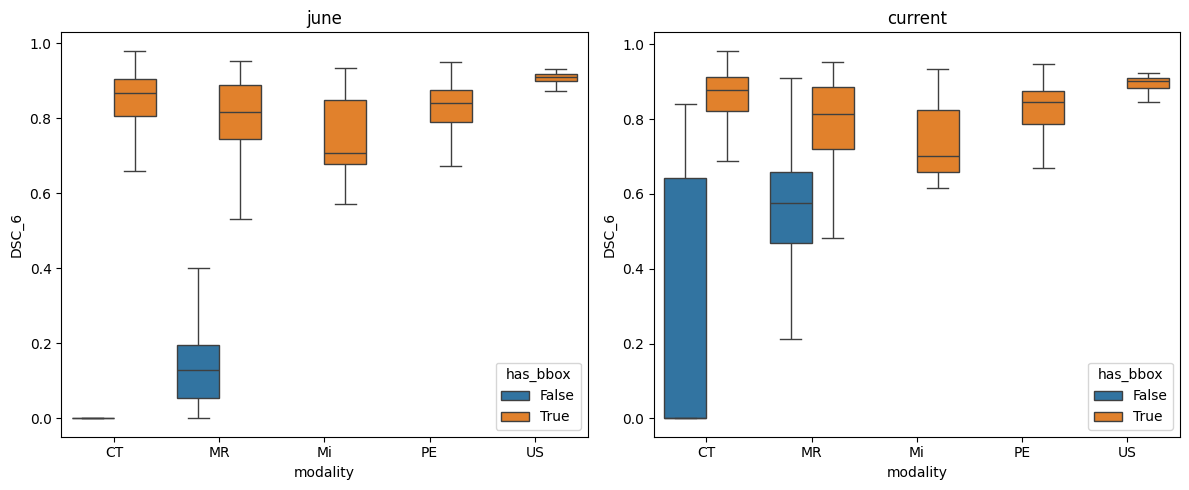

In [16]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=evalmetrics_june_df, x='modality', y='DSC_6', hue='has_bbox', 
            showfliers=False, ax=ax1)
ax1.set_title('june')
# Second boxplot
sns.boxplot(data=evalmetrics_current_df, x='modality', y='DSC_6', hue='has_bbox', 
            showfliers=False, ax=ax2)
ax2.set_title('current')

plt.tight_layout()
plt.show()

In [17]:
print( len(evalmetrics_current_df))


evalmetrics_june_df[final_metrics].mean(), evalmetrics_current_df[final_metrics].mean()

2116


(DSC_AUC      2.476568
 NSD_AUC      2.567562
 DSC_Final    0.637700
 NSD_Final    0.661532
 dtype: float64,
 DSC_AUC      2.841303
 NSD_AUC      3.056372
 DSC_Final    0.751093
 NSD_Final    0.813145
 dtype: float64)

In [18]:
evalmetrics_june_df[evalmetrics_june_df["has_bbox"] == False][final_metrics].mean(), evalmetrics_current_df[evalmetrics_current_df["has_bbox"] == False][final_metrics].mean()

(DSC_AUC      0.475911
 NSD_AUC      0.213223
 DSC_Final    0.149866
 NSD_Final    0.079863
 dtype: float64,
 DSC_AUC      1.738514
 NSD_AUC      1.869179
 DSC_Final    0.547950
 NSD_Final    0.602325
 dtype: float64)

In [19]:
evalmetrics_june_df[evalmetrics_june_df["has_bbox"] == True][final_metrics].mean(), evalmetrics_current_df[evalmetrics_current_df["has_bbox"] == True][final_metrics].mean()

(DSC_AUC      3.257376
 NSD_AUC      3.486404
 DSC_Final    0.828090
 NSD_Final    0.888544
 dtype: float64,
 DSC_AUC      3.271696
 NSD_AUC      3.519704
 DSC_Final    0.830375
 NSD_Final    0.895422
 dtype: float64)

In [50]:
print(evalmetrics_june_df.groupby(['modality', 'has_bbox'])[final_metrics].mean(),evalmetrics_current_df.groupby(['modality', 'has_bbox'])[final_metrics].mean())


                    DSC_AUC   NSD_AUC  DSC_Final  NSD_Final
modality has_bbox                                          
CT       False     0.185021  0.144307   0.062611   0.051421
         True      3.303202  3.414727   0.840520   0.873149
MR       False     0.488159  0.216125   0.153540   0.081061
         True      3.143812  3.570800   0.798675   0.907690
Mi       True      2.944780  3.809460   0.752430   0.960369
PE       True      3.236272  3.051659   0.820630   0.779322
US       True      3.596653  3.786931   0.907297   0.957002                     DSC_AUC   NSD_AUC  DSC_Final  NSD_Final
modality has_bbox                                          
CT       False     0.778442  0.620856   0.237051   0.198411
         True      3.344920  3.468538   0.850703   0.885869
MR       False     1.778938  1.921740   0.561040   0.619332
         True      3.119313  3.573159   0.790154   0.905799
Mi       True      2.898466  3.827061   0.735597   0.962909
PE       True      3.285542  3.148113   

In [35]:
evalmetrics_current_df[evalmetrics_current_df["has_bbox"] == False].TotalRunningTime.sum()/3600

8.00588619808356